In [2]:
#from a fieldmap in straight coordinates to one in curved coordinates
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s
from scipy.integrate import cumulative_trapezoid as cumtrapz 

(0.0, 1.0)

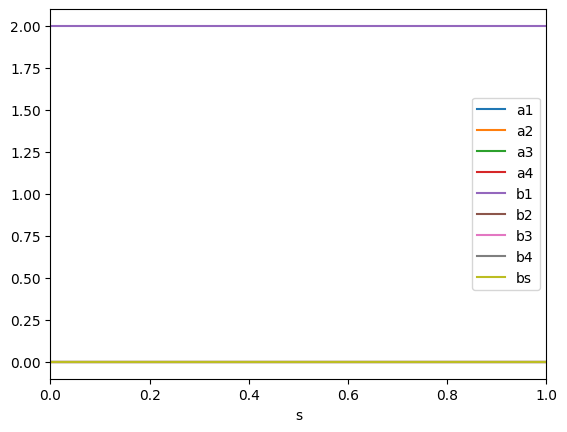

In [3]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [0,0, 0, 0]
b_coeffs = [2,0,0, 0]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
expansion.plot_components()
plt.xlabel('s')
plt.xlim((0,1))

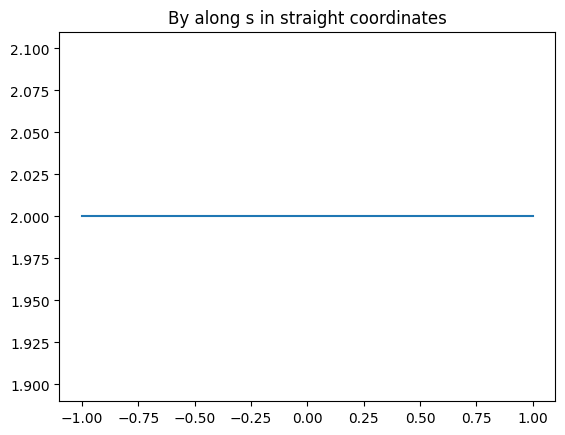

In [4]:
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(-1,1,101)

# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func) with lambdify=False
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_num = Bx_func(X, Y, S)
By_num = By_func(X, Y, S)
Bs_num = Bs_func(X, Y, S)
#print("Bx shape:", Bx_num.shape, "By shape:", By_num.shape, "Bs shape:", Bs_num.shape)
# X, Y, S  from meshgrid in straight frame
# Bx_ana, By_ana, Bs_ana are the corresponding field arrays
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_num.ravel(),
    By_num.ravel(),
    Bs_num.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)
plt.plot(sa, By_num[0,0,:], label='By along s at x=0,y=0')
plt.title('By along s in straight coordinates')
plt.show()

Curved data shape (N, 6): (2000000, 6)
Curved B field shapes: (2000000,) (2000000,) (2000000,)
Bx_fs reshaped shape: (100, 100, 200)


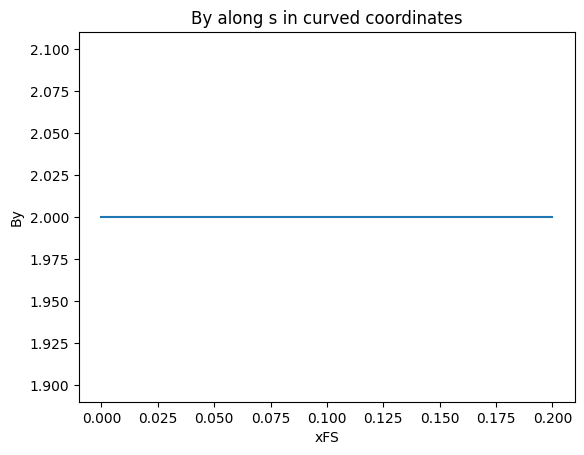

In [5]:
rho = .5
phi = 0.5
N=100
xFS = np.linspace(0, 0.2, N)
yFS = np.linspace(0, 0.2, N)
sFS = np.linspace(-rho*phi, rho*phi, 200)
interp_rad=0.025
fm_fs = fm.calc_FS_coords(xFS, yFS, sFS, rho, phi, radius=interp_rad)
datacurved= fm_fs.get_data()
print("Curved data shape (N, 6):", datacurved.shape)
Bxcurved = datacurved[:, 3]
Bycurved = datacurved[:, 4]    
Bscurved = datacurved[:, 5]
print("Curved B field shapes:", Bxcurved.shape, Bycurved.shape, Bscurved.shape)
Bx_fs_reshaped = Bxcurved.reshape(len(xFS), len(yFS), len(sFS))
By_fs_reshaped = Bycurved.reshape(len(xFS), len(yFS), len(sFS))
Bs_fs_reshaped = Bscurved.reshape(len(xFS), len(yFS), len(sFS))
print("Bx_fs reshaped shape:", Bx_fs_reshaped.shape)
plt.plot(xFS, By_fs_reshaped[:,5,5], label='By along x')
plt.title('By along s in curved coordinates')
plt.xlabel('xFS')
plt.ylabel('By')
plt.show()

$\vec{A}$ can be recovered from\
$
\begin{align}
    A_x(x, y, s) &= -\int_0^y B_s(x, \tilde{y}, s)  \; d\tilde{y} \\
    A_y(x, y, s) &= 0 \\
    A_s(x, y, s) &= \int_0^y B_x(x, \tilde{y}, s) \; d\tilde{y} - \frac{1}{1+hx} \int_0^x (1+h\tilde{x}) B_y(\tilde{x}, 0, s) \; d\tilde{x}
\end{align}$

Acurved shapes: (100, 100, 200) (100, 100, 200) (100, 100, 200)


Text(0, 0.5, 'As')

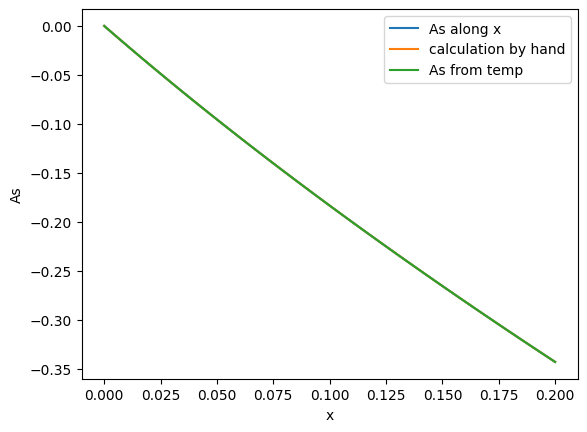

In [6]:
Acurvedx= -cumtrapz(Bs_fs_reshaped, yFS,axis=1, initial=0)#indefinite integral with scipy
Acurvedy= np.zeros_like(Acurvedx)
                       
factor = (1 + xFS / rho)[:, np.newaxis, np.newaxis]
# plt.plot(xFS, factor[:,0,0], label='Factor (1 + x/rho)')
# plt.plot(xFS, (factor * By_fs_reshaped[:,:,:])[:,0,0], label='Factor (1 + x/rho)')
# plt.show()
temp= cumtrapz(factor * By_fs_reshaped, xFS, axis=0, initial=0)#without specifying y=0
for i in range(len(yFS)):
    temp[:,i,:]=temp[:,0,:] #specifying here y=0 
Acurveds= cumtrapz(Bx_fs_reshaped[:,:,:], yFS,axis=1, initial=0) - (1 / factor) * temp
print("Acurved shapes:", Acurvedx.shape, Acurvedy.shape, Acurveds.shape)
plt.plot(xFS, Acurveds[:,9,9], label='As along x')
myAscalculation = - xFS * (1/(1+xFS/rho) +1)
plt.plot(xFS, myAscalculation, label='calculation by hand')
plt.plot(xFS,- (1 / factor[:,0,0]) * temp[:,9,9], label='As from temp')
plt.legend()
plt.xlabel('x')
plt.ylabel('As')

And then back to the $\vec{B}$ field:\
$ \begin{align}
    \mathbf{B} &= \nabla\times\mathbf{A}  =
    \left(\partial_y A_s - \frac{\partial_s  A_y}{1+h x} \right) \mathbf{\hat{x}} 
    +\left(\frac{\partial_s A_x-\partial_x (1+h x) A_s }{1+h x} \right)\mathbf{\hat{y}} \nonumber 
    & +\left(\partial_x A_y - \partial_y A_x \right) \mathbf{\hat{s}} \,.
\end{align} $

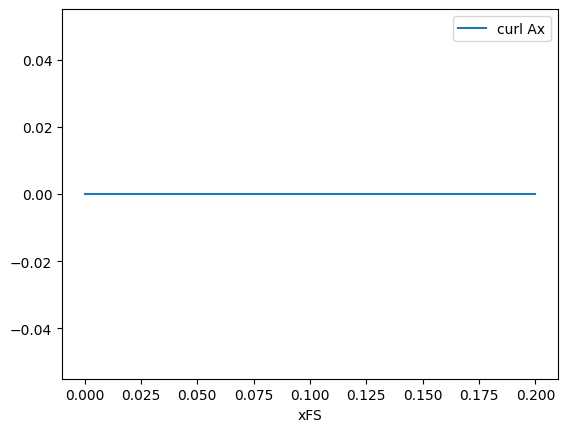

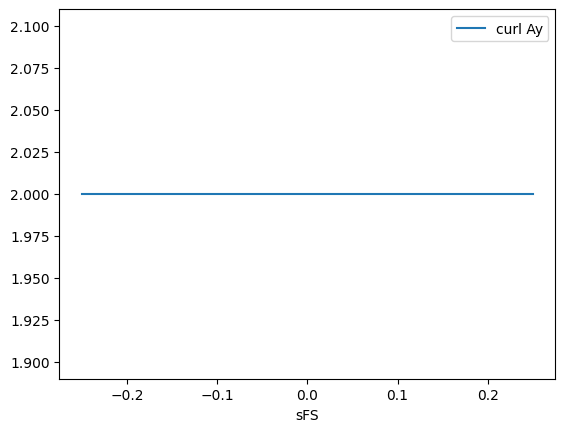

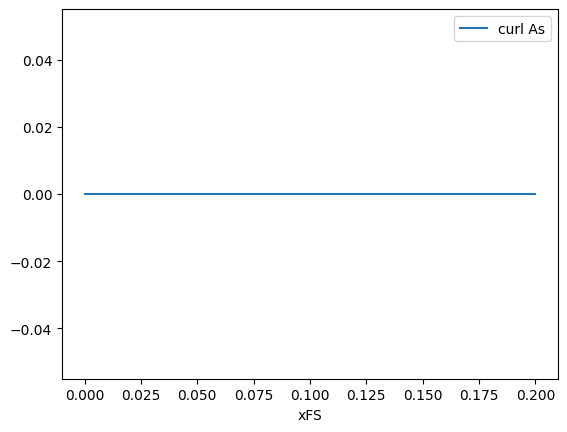

In [7]:
def curl_curved(Ax, Ay, As, dx, dy, ds, h):
  
    # Compute partial derivatives
    dAx_dy = np.gradient(Ax, dy, axis=1)
    dAx_ds = np.gradient(Ax, ds, axis=2)
    dAy_dx = np.gradient(Ay, dx, axis=0)
    dAy_ds = np.gradient(Ay, ds, axis=2)
    factor = (1 + xFS *h)[:, np.newaxis, np.newaxis]
    d1plushxAs_dx = np.gradient(factor*As, dx, axis=0)
    dAs_dy = np.gradient(As, dy, axis=1)
    # Curl components
    curl_x = dAs_dy - dAy_ds/factor
    curl_y = (dAx_ds - d1plushxAs_dx)/factor
    curl_s = dAy_dx - dAx_dy
    
    return curl_x, curl_y, curl_s
curlAx, curlAy, curlAs = curl_curved(Acurvedx, Acurvedy, Acurveds, xFS[1]-xFS[0], yFS[1]-yFS[0], sFS[1]-sFS[0], 1/rho)

plt.plot(xFS, curlAx[:,0,0], label='curl Ax')
plt.legend()
plt.xlabel('xFS')
plt.show()

plt.plot(sFS, curlAy[7,7,:], label='curl Ay')
plt.xlabel('sFS')
plt.legend()
plt.show()

plt.plot(xFS, curlAs[:,0,0], label='curl As')
plt.xlabel('xFS')
plt.legend()
plt.show()

In [ ]:
Xfs, Yfs, Sfs = np.meshgrid(xFS, yFS, sFS, indexing='ij')
datafieldmap = np.column_stack([
    Xfs.ravel(),
    Yfs.ravel(),
    Sfs.ravel(),
    curlAx.ravel(),
    curlAy.ravel(),
    curlAs.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm_curved = bpmeth.fieldmaps.Fieldmap(datafieldmap)#create a fieldmap object with the B field data in curved coordinates
fm_curved.plot()

In [9]:
print(xFS[0], xFS[N-1], xFS[N-2])
print(len(xFS[1:N-1]))

0.0 0.2 0.19797979797979798
98


In [12]:
# Choose a fixed s value (s=0 is the magnet center)
s_fixed = 0.05
interp_rad=0.001 #can change the running time and results a lot
bnianHA=fm_curved.harmonic_analysis_at_s(spos=s_fixed,rmin=xFS[1],rmax=xFS[N-1],nr=N-1,radius=interp_rad)
print("recovered bn(s=",s_fixed,") in curved frame: ", bnianHA.real)


recovered bn(s= 0.05 ) in curved frame:  [0. 0. 0. 0. 0.]


The harmonic analysis can be made as a function of the s position.

In [13]:
svals, bnofs, errorbn = fm_curved.s_harmonics(order=4, rmin=0.002, rmax= 0.2, nr=N-1, radius=interp_rad)

KeyboardInterrupt: 

(200, 4)


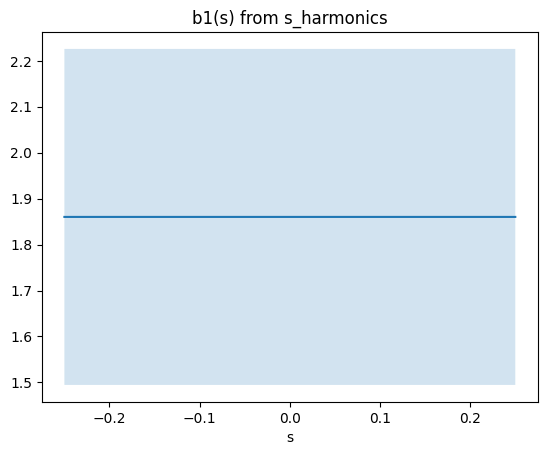

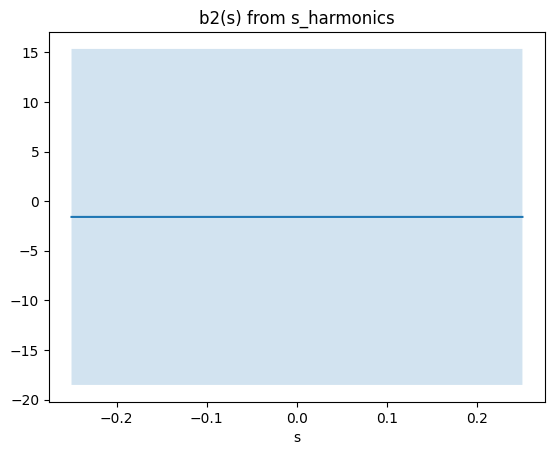

In [ ]:
print(bnofs.shape)
plt.plot(svals, bnofs[:,0])
plt.fill_between(svals, bnofs[:,0]-errorbn[:,0], bnofs[:,0]+errorbn[:,0], alpha=0.2)
plt.xlabel('s')
plt.title('b1(s) from s_harmonics')
plt.show()
plt.plot(svals, bnofs[:,1])
plt.fill_between(svals, bnofs[:,1]-errorbn[:,1], bnofs[:,1]+errorbn[:,1], alpha=0.2)
plt.xlabel('s')
plt.title('b2(s) from s_harmonics')
plt.show()

Then I can use the analytic formulas for the conversion of the b_n coefficients from the curved to the straight frame.\
$\breve{b_1}(\breve{s})=b_1{\rho[\theta_E-\arctan(\tan \theta_E-\frac{\breve{s}}{\rho \cos \theta_E})]}+b_2[\rho[\theta_E-\arctan(\tan \theta_E -\frac{\breve{s}}{\rho \cos \theta_E})]](\sqrt{\rho^2 -2\rho \sin\theta_E \breve{s} +\breve{s}^2}-\rho )$

In [ ]:
import sympy
#evaluate the original coefficients at s=s_fixed to compare original and recovered coefficients asa fucntions of s
a_coeffs_eval = [sympy.sympify(coeff).subs(s, svals) for (coeff, svals) in zip(a_coeffs, svals)]
b_coeffs_eval = [sympy.sympify(coeff).subs(s, svals) for (coeff, svals) in zip(b_coeffs, svals)]

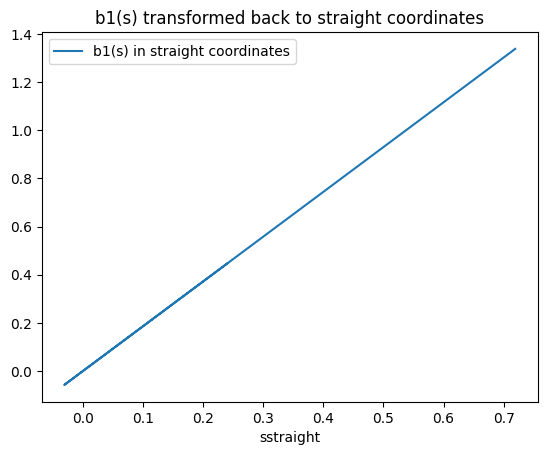

In [ ]:
thetaE=0.
xx=np.linspace(-1,1, 2*N)#to match dimension of svals
sstraight = rho*np.sin(thetaE)-(rho+xx)*np.sin(thetaE- sFS/rho)#?
b1straight = bnofs[:,0]*rho*(thetaE-np.arctan(np.tan(thetaE-sstraight/rho/np.cos(thetaE)))) + bnofs[:,1]*(rho*(thetaE-np.arctan(np.tan(thetaE-sstraight/rho/np.cos(thetaE))))*(np.sqrt(rho**2 -2*rho*np.sin(thetaE)*sstraight*sstraight**2)-rho))
plt.plot(sstraight, b1straight, label='b1(s) in straight coordinates')
plt.xlabel('sstraight')
plt.title('b1(s) transformed back to straight coordinates')
plt.legend()

plt.plot(sstraight, b_coeffs_eval[0], label='original b1(s) in straight coordinates')
plt.show()